# Constraints and costs

Real mandates are not unconstrained. You cap concentration, hold a sector band, limit how much
you trade at each rebalance, and pay transaction costs. In `PortfolioOptimisers.jl` these are
**keywords on the `JuMPOptimiser`** — the optimiser carries the constraints and costs,
the estimator carries the objective. This page shows the common ones with one minimal call
each; for the full treatment see the
[constraints & costs examples](../examples/4_constraints_costs/01_Budget_Constraints.md).

We fix one empirical prior and a minimum-risk objective so each keyword's effect is visible
against the same baseline.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res_base = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 1. Weight bounds

`WeightBounds` sets the per-asset lower and upper bound through the `wb` keyword. The
default is `lb = 0, ub = 1` (long-only, fully invested). Capping `ub` forces diversification —
no single name can exceed the bound.

In [2]:
res_cap = optimise(MeanRisk(; obj = MinimumRisk(),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                wb = WeightBounds(; lb = 0.0, ub = 0.10))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

The budget itself is the `bgt` keyword (default `1.0`); `BudgetRange` and a separate short
budget `sbgt` let you build long/short and leveraged mandates — see
[Budget Constraints](../examples/4_constraints_costs/01_Budget_Constraints.md).

## 2. Linear and group constraints

Group and linear constraints are written as plain strings over an `AssetSets` and passed
through `lcse` as a `LinearConstraintEstimator` — the same syntax used for views. Name a
group, then bound it. Here we require the tech group to hold at least 15% (a floor the
unconstrained minimum-risk portfolio would not give it).

In [3]:
sets = AssetSets(; dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"]))
res_grp = optimise(MeanRisk(; obj = MinimumRisk(),
                            opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                lcse = LinearConstraintEstimator(;
                                                                                 val = ["tech >= 0.15"]))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

The same `lcse` handles absolute and relative bounds (`"AAPL <= 0.1"`, `"MSFT >= AMD"`). For
constraints built from the asset *hierarchy* — phylogeny and centrality — see
[Phylogeny & Centrality](../examples/4_constraints_costs/04_Phylogeny_Centrality.md).

## 3. Turnover

Costs enter the same way. `Turnover` (`tn`) limits how far the new weights may drift
from a reference portfolio `w` — your current holdings — so a rebalance stays cheap. Here we
anchor at the current minimum-risk portfolio and re-solve under a turnover budget.

In [4]:
res_tn = optimise(MeanRisk(; obj = MinimumRisk(),
                           opt = JuMPOptimiser(; pe = pr, slv = slv,
                                               tn = Turnover(; w = res_base.w, val = 0.02))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

A tighter `val` keeps the result closer to the reference holdings; a looser one frees the
optimiser to move toward the unconstrained solution.

## 4. Fees

`Fees` (`fees`) charges proportional (and optionally fixed) transaction costs on long
and short positions, which the objective then trades off against return. The minimal form sets a
per-unit long fee.

In [5]:
res_fee = optimise(MeanRisk(; obj = MaximumRatio(; rf = 4.2 / 100 / 252),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                fees = Fees(; l = 0.001))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

Soft alternatives to hard turnover/position limits — L1/L2 weight regularisation and a
weight-norm ceiling that doubles as a diversification floor (`l1`, `l2`, `l2c`) — are covered in
[Regularisation](../examples/4_constraints_costs/07_Regularisation.md); benchmark
`Tracking` (the `tr` keyword) in
[Turnover & Tracking](../examples/4_constraints_costs/05_Turnover_and_Tracking.md).

## 5. Custom objectives and constraints

When a mandate needs something no built-in keyword covers, two `JuMPOptimiser` extension
points let you write straight against the JuMP model. Each takes an estimator (or a vector of
them) and dispatches on its type:

  - `cobj` takes a `CustomJuMPObjective` — implement `add_custom_objective_term!`
    to add a term to the objective expression.
  - `ccnt` takes a `CustomJuMPConstraint` — implement `add_custom_constraint!` to
    add a constraint to the model.

To show both, we tilt toward a *momentum score* — each asset's standardised trailing-63-day
return. It is a continuous per-asset number, so no group string could express it.

In [6]:
using JuMP: JuMP

score = let m = vec(sum(rd.X[(end - 62):end, :]; dims = 1))
    (m .- mean(m)) ./ std(m)
end

20-element Vector{Float64}:
 -2.4665402136615917
 -1.4413572531253842
 -0.3612671090853615
  0.9566903130742512
  0.9699080889998929
  1.3627828961331052
  0.18785281642803764
 -0.38862209725210817
  1.0748533658071462
  0.09877497281958833
 -0.1176288187098377
  1.4032396935255864
 -1.0858314183746478
 -0.2340678807675684
  0.381198819163341
  0.3959530097742231
 -0.6829500082854164
 -0.6890663510571217
 -0.382411265465787
  1.0184884400596512

**A custom objective.** Subtype `CustomJuMPObjective` and mutate the objective
expression. `MinimumRisk` is a *minimisation*, so we *subtract* the score reward (scaled by
`lambda`) to favour high-momentum names; read the weight variables with the `get_w`
accessor rather than reaching into `model[:w]` directly.

In [7]:
struct MomentumTilt{T1, T2} <: PortfolioOptimisers.CustomJuMPObjective
    score::T1
    lambda::T2
end
function PortfolioOptimisers.add_custom_objective_term!(model::JuMP.Model, obj, pret,
                                                        cobj::MomentumTilt, obj_expr, opt,
                                                        pr, args...)
    sign = ifelse(isa(obj, MinimumRisk), -1, 1)
    w = PortfolioOptimisers.get_w(model)
    JuMP.add_to_expression!(obj_expr, sign * cobj.lambda * (cobj.score' * w))
    return nothing
end

res_tilt = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                 cobj = MomentumTilt(score, 1e-4))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

**A custom constraint.** Subtype `CustomJuMPConstraint` and add a JuMP constraint,
following the model idiom: scale the constraint by `get_constraint_scale` and multiply
any constant bound by the homogenisation variable `get_k` (`1` here, but load-bearing
under a ratio objective). This puts a hard *floor* on the same momentum exposure.

In [8]:
struct MomentumFloor{T1, T2} <: PortfolioOptimisers.CustomJuMPConstraint
    score::T1
    floor::T2
end
function PortfolioOptimisers.add_custom_constraint!(model::JuMP.Model, ccnt::MomentumFloor,
                                                    opt, attrs)
    w = PortfolioOptimisers.get_w(model)
    k = PortfolioOptimisers.get_k(model)
    sc = PortfolioOptimisers.get_constraint_scale(model)
    JuMP.@constraint(model, sc * (ccnt.score' * w - ccnt.floor * k) >= 0)
    return nothing
end

res_floor = optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                  ccnt = MomentumFloor(score, 1.0))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

Both lift the portfolio's momentum exposure `score'w` above the baseline — the soft tilt as far
as the risk trade-off allows, the hard floor to exactly its bound.

In [9]:
momentum_exposure = (base = score' * res_base.w, tilt = score' * res_tilt.w,
                     floor = score' * res_floor.w)

(base = 0.2042109183638675, tilt = 1.2953518927607823, floor = 1.0000001371634168)

## 6. Comparing the effect

Same prior, same objective — only the constraint or cost changes the allocation.

                      Weights under each constraint / cost
┌────────┬──────────┬─────────┬────────────┬──────────┬──────────┬──────────────
│  Asset │     Base │ Cap 10% │ Tech ≥ 15% │ Turnover │     Fees │ Momentum ti ⋯
│ String │  Float64 │ Float64 │    Float64 │  Float64 │  Float64 │       Float ⋯
├────────┼──────────┼─────────┼────────────┼──────────┼──────────┼──────────────
│   AAPL │    0.0 % │   0.0 % │    0.297 % │    0.0 % │    0.0 % │        -0.0 ⋯
│    AMD │    0.0 % │   0.0 % │      0.0 % │    0.0 % │    0.0 % │        -0.0 ⋯
│    BAC │    0.0 % │   0.0 % │      0.0 % │    0.0 % │    0.0 % │         0.0 ⋯
│    BBY │    0.0 % │   0.0 % │      0.0 % │    0.0 % │    0.0 % │       1.296 ⋯
│    CVX │  7.432 % │  10.0 % │    3.765 % │  7.414 % │    0.0 % │       5.704 ⋯
│     GE │  0.806 % │ 0.242 % │      0.0 % │  0.813 % │    0.0 % │       9.022 ⋯
│     HD │    0.0 % │ 0.717 % │      0.0 % │    0.0 % │    0.0 % │         0.0 ⋯
│    JNJ │ 36.974 % │  10.0 % │   37.455 % │ 36.97

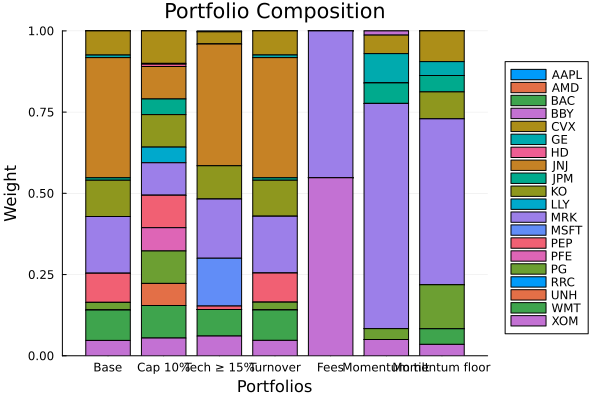

In [10]:
results = [res_base, res_cap, res_grp, res_tn, res_fee, res_tilt, res_floor]
labels = ["Base", "Cap 10%", "Tech ≥ 15%", "Turnover", "Fees", "Momentum tilt",
          "Momentum floor"]

pretty_table(DataFrame(["Asset" => rd.nx,
                        [labels[i] => results[i].w for i in eachindex(results)]...]);
             formatters = [resfmt], title = "Weights under each constraint / cost")

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*